In [8]:
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

In [9]:
data = load_data()

/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [10]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

In [11]:
check_stationarity(data_sd["t_seasdiff"], regression='c')

ADF Statistic: -7.2188813814276775
p-value: 2.1371308431550362e-10
Stationary
KPSS Statistic: 0.01921813204590542
p-value: 0.1
Stationary


/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


In [16]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(
    data_sd['t_seasdiff'],
    m=12,
    max_p=3,
    max_q=2,
    max_P=12,
    max_Q=12,
    max_lag=100
)
acf_res = cand_res["acf"]
pacf_res = cand_res["pacf"]
print(acf_res)
print(pacf_res)
candidates = cand_res["candidates"]

for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

[ 1.00000000e+00  2.22765750e-01  1.99895453e-01  3.38474338e-02
  5.33025567e-02 -2.64157512e-02 -4.70244273e-02 -1.49413484e-02
 -7.45338913e-02 -6.66100133e-02 -1.27817624e-01 -8.56421695e-02
 -4.80824459e-01 -1.05541753e-01 -1.42207100e-01  1.65059961e-02
  1.45520662e-02  4.19113544e-02  6.07335141e-02  2.21687872e-02
  3.49323265e-02  5.68790869e-02  7.36469853e-03 -1.33342073e-02
 -4.21466624e-02  5.69385547e-03  1.13527502e-02 -2.24844275e-02
 -6.28698494e-02 -1.31350440e-02 -3.60395127e-02 -4.34022331e-02
 -5.00234269e-02 -2.69426719e-02  1.32812491e-01  5.88776611e-03
  1.02046082e-01 -4.77711257e-02 -2.87108118e-03 -4.44601435e-02
  6.08921996e-02 -2.57170370e-02  4.73424252e-02  9.65040735e-02
  5.69959193e-02 -1.13876691e-02 -1.63569531e-01  4.69283482e-02
 -6.07313034e-02  4.85336023e-02  2.35252745e-02  6.50359943e-02
  2.55300148e-03  4.35591197e-02 -3.71711761e-02 -1.16539000e-01
 -7.04969244e-02 -3.53662358e-02  4.65015531e-02 -9.64583701e-02
 -2.52005808e-02 -6.97096

In [17]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target='t_seasdiff',
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)
print(best_info["results"].summary())

/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum

Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4613, MAE=1.0263
Tried SARIMA(0,0,0)(6,0,0,12) -> RMSE=1.7715, MAE=1.2735


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


...

Tried SARIMA(2,0,2)(3,0,1,12) -> RMSE=1.2682, MAE=0.9563


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Tried SARIMA(2,0,2)(6,0,0,12) -> RMSE=1.2916, MAE=0.9996


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Tried SARIMA(2,0,2)(6,0,1,12) -> RMSE=1.2817, MAE=0.9863

Best model found:
(p,d,q) = (2, 0, 0), (P,D,Q,s) = (2, 0, 1, 12), RMSE = 1.2149, MAE = 0.8889
                                      SARIMAX Results                                       
Dep. Variable:                           t_seasdiff   No. Observations:                  108
Model:             SARIMAX(2, 0, 0)x(2, 0, [1], 12)   Log Likelihood                -198.136
Date:                              Fri, 12 Dec 2025   AIC                            408.272
Time:                                      10:18:10   BIC                            424.365
Sample:                                  02-01-2010   HQIC                           414.797
                                       - 01-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.26 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.06 sec
 ARIMA(1,0,0)(3,0,0)[12] intercept   : AIC=415.230, Time=0.18 sec
 ARIMA(1,0,0)(4,0,0)[12] intercept   : AIC=415.140, Time=0.36 sec
 ARIMA(1,0,0)(5,0,0)[12] intercept   : AIC=409.505, Time=1.09 sec
 ARIMA(1,0,0)(6,0,0)[12] intercept   : AIC=inf, Time=1.60 sec
 ARIMA(1,0,0)(5,0,1)[12] intercept   : AIC=408.050, Time=1.46 sec
 ARIMA(1,0,0)(4,0,1)[12] intercept   : AIC=inf, Time=1.67 sec
 ARIMA(1,0,0)(6,0,1)[12] intercept   : AIC=409.587, Time=2.35 sec
 ARIMA(1,0,0)(5,0,2)[12] intercept   : AIC=inf, Time=4.21 sec
 ARIMA(1,0,0)(4,0,2)[12] intercept   : AIC=inf, T

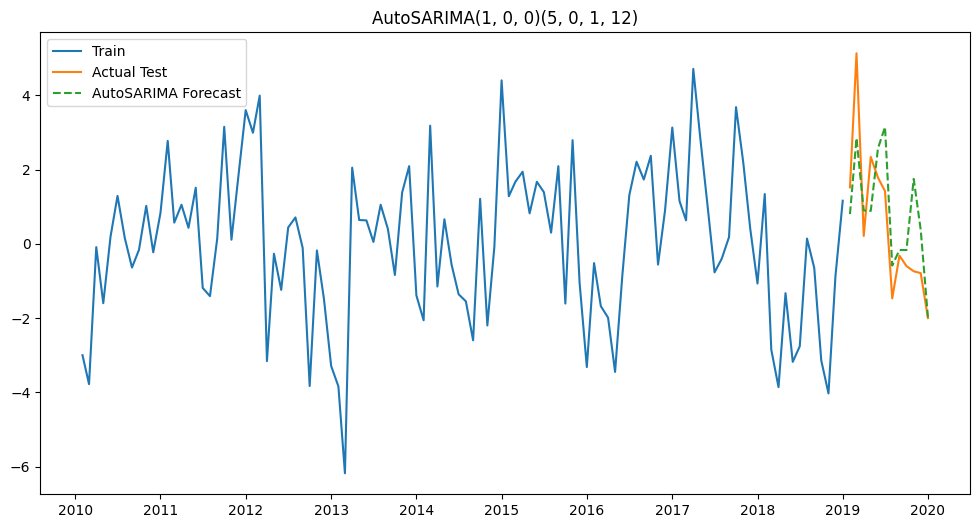

{'order': (1, 0, 0),
 'seasonal_order': (5, 0, 1, 12),
 'rmse': 1.3059232141969157,
 'mae': 1.0664310482875596,
 'model': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(5, 0, 1, 12),
       suppress_warnings=True),
 'forecast': date
 2019-02-01    0.799370
 2019-03-01    2.844089
 2019-04-01    0.897181
 2019-05-01    0.885072
 2019-06-01    2.569484
 2019-07-01    3.144393
 2019-08-01   -0.586590
 2019-09-01   -0.167952
 2019-10-01   -0.169065
 2019-11-01    1.747486
 2019-12-01    0.375165
 2020-01-01   -1.984400
 dtype: float64,
 'test': date
 2019-02-01    1.52
 2019-03-01    5.13
 2019-04-01    0.21
 2019-05-01    2.34
 2019-06-01    1.78
 2019-07-01    1.42
 2019-08-01   -1.47
 2019-09-01   -0.32
 2019-10-01   -0.60
 2019-11-01   -0.74
 2019-12-01   -0.79
 2020-01-01   -2.00
 Name: t_seasdiff, dtype: float64}

In [14]:
auto_sarima_experiment(data_sd, target='t_seasdiff',forecast_window=12, no_windows=10, max_P=12, max_Q=12, max_p=12, max_q=12, m=12)